## Exploring DMEPOS-By Supplier & Service

This is the intital exploration and cleaning done before data from 2021-2023 are combined.

Note: This is for testing purposes only.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
for f in Path("/dsa/groups/casestudycf25/team02/").iterdir():
    print(f.name)

DMEPOS_suplr_2021.csv
Medicare_Monthly_Enrollment_Jun_2025.csv
DMEPOS_suplr_2022.csv
DMEPOS_suplr_2023.csv
DMEPOS_Supplier_Service_2021.csv
DMEPOS_Supplier_Service_2022.csv
DMEPOS_Supplier_Service_2023.csv
LEIE_OIG_Exclusion_List.csv
mup_dme_ry25_p05_v10_dy21_rfrhpr.csv
mup_dme_ry25_p05_v10_dy21_rfrr.csv
mup_dme_ry25_p05_v10_dy22_rfrhpr.csv
mup_dme_ry25_p05_v10_dy22_rfrr.csv
mup_dme_ry25_p05_v10_dy23_rfrhpr.csv
mup_dme_ry25_p05_v10_dy23_rfrr.csv
RUCA2010zipcode.csv
Taxonomy Code List Dec 2023.csv
leie_with_null_npi_clean.csv
leie_with_valid_npi_clean.csv
medicare_enrollment_clean.csv
CMS_General_Payments_2021_2023_raw.csv
casestudycf25t02.sqlite.db
DMEPOS_Bene_only_suplr.csv
DMEPOS_rfrhpr_clean.csv
DMEPOS_rfrr_clean.csv
DMEPOS_cleaned_serv.csv
DMEPOS_cleaned_grouping.csv
OWNRSHP_PGYR2021_2023.csv
ownership_payment_clean.csv
DMEPOS_rfrhpr_clean_labeled.csv
DMEPOS_rfrr_clean_labeled.csv
general_payments_manufacturers_clean.csv
general_payments_providers_clean.csv
general_payments-sliced_

In [3]:
#Sincs its EDA, I will be exploring only the 2023 dataset.
header = pd.read_csv("/dsa/groups/casestudycf25/team02/DMEPOS_Supplier_Service_2023.csv",nrows=0).columns

for i in header:
    print(i)

Suplr_NPI
Suplr_Prvdr_Last_Name_Org
Suplr_Prvdr_First_Name
Suplr_Prvdr_MI
Suplr_Prvdr_Crdntls
Suplr_Prvdr_Ent_Cd
Suplr_Prvdr_St1
Suplr_Prvdr_St2
Suplr_Prvdr_City
Suplr_Prvdr_State_Abrvtn
Suplr_Prvdr_State_FIPS
Suplr_Prvdr_Zip5
Suplr_Prvdr_RUCA_Cat
Suplr_Prvdr_RUCA
Suplr_Prvdr_RUCA_Desc
Suplr_Prvdr_Cntry
Suplr_Prvdr_Spclty_Cd
Suplr_Prvdr_Spclty_Desc
Suplr_Prvdr_Spclty_Srce
RBCS_Lvl
RBCS_Id
RBCS_Desc
HCPCS_Cd
HCPCS_Desc
Suplr_Rentl_Ind
Tot_Suplr_Benes
Tot_Suplr_Clms
Tot_Suplr_Srvcs
Avg_Suplr_Sbmtd_Chrg
Avg_Suplr_Mdcr_Alowd_Amt
Avg_Suplr_Mdcr_Pymt_Amt
Avg_Suplr_Mdcr_Stdzd_Amt


In [4]:
#Loading the data
df = pd.read_csv("/dsa/groups/casestudycf25/team02/DMEPOS_Supplier_Service_2023.csv",dtype={"Suplr_Prvdr_RUCA": "float64"})

In [5]:
df.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,HCPCS_Cd,HCPCS_Desc,Suplr_Rentl_Ind,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3808,"Wrist hand finger orthosis, rigid without join...",N,38.0,39,39,540.000000,371.79,289.320256,300.242820
1,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3906,"Wrist hand orthosis, without joints, may inclu...",N,27.0,27,28,555.178571,528.91,414.603214,361.113214
2,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3908,"Wrist hand orthosis, wrist extension control c...",N,57.0,57,63,112.619048,76.52,59.047619,53.890794
3,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3923,"Hand finger orthosis, without joints, may incl...",N,24.0,24,27,115.000000,100.82,78.927778,79.388148
4,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3925,"Finger orthosis, proximal interphalangeal (pip...",N,13.0,13,13,99.769231,68.56,42.296154,34.993077


In [6]:
#Shape of dataset
print(f"No. of data entries: {df.shape[0]}")
print(f"No. of attributes: {df.shape[1]}")

No. of data entries: 463784
No. of attributes: 32


In [7]:
#Looking into descriptive stats
df.describe()

,Suplr_NPI,Suplr_Prvdr_State_FIPS,Suplr_Prvdr_Zip5,Suplr_Prvdr_RUCA,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
count,4.637840e+05,463784.000000,463784.000000,463712.000000,273413.000000,463784.000000,4.637840e+05,463784.000000,463784.000000,463784.000000,463784.000000
mean,1.503161e+09,28.496850,49387.194243,2.135779,101.697282,171.425733,5.505812e+03,222.699130,112.044663,85.875260,86.607453
std,2.881522e+08,15.541546,27633.529098,2.632372,686.977205,2144.483552,5.876363e+05,984.379411,464.498442,360.695164,354.199617
min,1.003000e+09,1.000000,605.000000,1.000000,11.000000,11.000000,1.100000e+01,0.010000,0.006902,0.000000,0.000000
25%,1.255448e+09,17.000000,28401.000000,1.000000,16.000000,16.000000,2.600000e+01,13.875455,3.150000,2.407374,2.474473
50%,1.508845e+09,28.000000,47001.000000,1.000000,28.000000,29.000000,9.200000e+01,40.000000,18.103448,13.319546,13.510742
75%,1.750350e+09,42.000000,73108.000000,2.000000,65.000000,77.000000,6.760000e+02,125.000000,61.810000,45.816514,49.054652
max,1.992999e+09,78.000000,99901.000000,99.000000,112797.000000,859097.000000,2.967321e+08,77612.100000,27733.260000,21742.880000,21496.420000


In [8]:
#Data types
df.dtypes

Suplr_NPI                      int64
Suplr_Prvdr_Last_Name_Org     object
Suplr_Prvdr_First_Name        object
Suplr_Prvdr_MI                object
Suplr_Prvdr_Crdntls           object
Suplr_Prvdr_Ent_Cd            object
Suplr_Prvdr_St1               object
Suplr_Prvdr_St2               object
Suplr_Prvdr_City              object
Suplr_Prvdr_State_Abrvtn      object
Suplr_Prvdr_State_FIPS         int64
Suplr_Prvdr_Zip5               int64
Suplr_Prvdr_RUCA_Cat          object
Suplr_Prvdr_RUCA             float64
Suplr_Prvdr_RUCA_Desc         object
Suplr_Prvdr_Cntry             object
Suplr_Prvdr_Spclty_Cd         object
Suplr_Prvdr_Spclty_Desc       object
Suplr_Prvdr_Spclty_Srce       object
RBCS_Lvl                      object
RBCS_Id                       object
RBCS_Desc                     object
HCPCS_Cd                      object
HCPCS_Desc                    object
Suplr_Rentl_Ind               object
Tot_Suplr_Benes              float64
Tot_Suplr_Clms                 int64
T

In [9]:
#Removing entries tied to Non-DME and Unknown (maybe Drugs Administered Through DME)
RBCS_lvl_ = ['Unknown', 'Non-DME']
df_clean = df[~df['RBCS_Lvl'].isin(RBCS_lvl_)]
df_clean.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,HCPCS_Cd,HCPCS_Desc,Suplr_Rentl_Ind,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3808,"Wrist hand finger orthosis, rigid without join...",N,38.0,39,39,540.000000,371.79,289.320256,300.242820
1,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3906,"Wrist hand orthosis, without joints, may inclu...",N,27.0,27,28,555.178571,528.91,414.603214,361.113214
2,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3908,"Wrist hand orthosis, wrist extension control c...",N,57.0,57,63,112.619048,76.52,59.047619,53.890794
3,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3923,"Hand finger orthosis, without joints, may incl...",N,24.0,24,27,115.000000,100.82,78.927778,79.388148
4,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3925,"Finger orthosis, proximal interphalangeal (pip...",N,13.0,13,13,99.769231,68.56,42.296154,34.993077


In [10]:
#Shape of dataset
print(f"No. of data entries: {df_clean.shape[0]}")
print(f"No. of attributes: {df_clean.shape[1]}")
#Around 80 thousand entries were removed, which is ~17% of the data. This is likely not a consistent value for the remaining datasets from the year 2021 and 2022.

No. of data entries: 386063
No. of attributes: 32


In [11]:
#Checking for Null counts
nulls = df_clean.isna().sum()

for i in nulls:
    print(i)
#Only Suplr_Prvdr_RUCA as null values.
# Suplr_Prvdr_RUCA entries with 99 are kept even though they are unknown.

0
0
385170
385427
385381
0
0
330286
0
0
0
0
63
63
63
0
0
0
0
0
0
0
0
0
0
128267
0
0
0
0
0
0


In [12]:
#Removing rows with missing Suplr_Prvdr_RUCA values
df_clean = df_clean[df_clean['Suplr_Prvdr_RUCA'].notna()]
df_clean.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,HCPCS_Cd,HCPCS_Desc,Suplr_Rentl_Ind,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3808,"Wrist hand finger orthosis, rigid without join...",N,38.0,39,39,540.000000,371.79,289.320256,300.242820
1,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3906,"Wrist hand orthosis, without joints, may inclu...",N,27.0,27,28,555.178571,528.91,414.603214,361.113214
2,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3908,"Wrist hand orthosis, wrist extension control c...",N,57.0,57,63,112.619048,76.52,59.047619,53.890794
3,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3923,"Hand finger orthosis, without joints, may incl...",N,24.0,24,27,115.000000,100.82,78.927778,79.388148
4,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,L3925,"Finger orthosis, proximal interphalangeal (pip...",N,13.0,13,13,99.769231,68.56,42.296154,34.993077


In [13]:
#Shape
print(f"No. of data entries: {df_clean.shape[0]}")
print(f"No. of attributes: {df_clean.shape[1]}")

No. of data entries: 386000
No. of attributes: 32


In [14]:
#String Columns
string_cols = df_clean.select_dtypes(include="object").columns.tolist()
string_cols

['Suplr_Prvdr_Last_Name_Org',
 'Suplr_Prvdr_First_Name',
 'Suplr_Prvdr_MI',
 'Suplr_Prvdr_Crdntls',
 'Suplr_Prvdr_Ent_Cd',
 'Suplr_Prvdr_St1',
 'Suplr_Prvdr_St2',
 'Suplr_Prvdr_City',
 'Suplr_Prvdr_State_Abrvtn',
 'Suplr_Prvdr_RUCA_Cat',
 'Suplr_Prvdr_RUCA_Desc',
 'Suplr_Prvdr_Cntry',
 'Suplr_Prvdr_Spclty_Cd',
 'Suplr_Prvdr_Spclty_Desc',
 'Suplr_Prvdr_Spclty_Srce',
 'RBCS_Lvl',
 'RBCS_Id',
 'RBCS_Desc',
 'HCPCS_Cd',
 'HCPCS_Desc',
 'Suplr_Rentl_Ind']

In [15]:
#Cleaning up string variables
import re

for c in string_cols:
    df_clean[c] = (
        df_clean[c]
        .astype(str)
        .str.lower()
        .str.replace(r"[^A-Za-z0-9\s]", "", regex=True)#remove special characters except letters, numbers, spaces
        .str.replace(r"\s+", "_", regex=True)
        .replace("", "na")#replace spaces with underscores
        .fillna("na")
    )

In [16]:
df_clean.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,HCPCS_Cd,HCPCS_Desc,Suplr_Rentl_Ind,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
0,1003000399,reconstructive_hand_to_shoulder_of_indiana_llc,nan,nan,nan,o,13431_old_meridian_street,suite_225,carmel,in,...,l3808,wrist_hand_finger_orthosis_rigid_without_joint...,n,38.0,39,39,540.000000,371.79,289.320256,300.242820
1,1003000399,reconstructive_hand_to_shoulder_of_indiana_llc,nan,nan,nan,o,13431_old_meridian_street,suite_225,carmel,in,...,l3906,wrist_hand_orthosis_without_joints_may_include...,n,27.0,27,28,555.178571,528.91,414.603214,361.113214
2,1003000399,reconstructive_hand_to_shoulder_of_indiana_llc,nan,nan,nan,o,13431_old_meridian_street,suite_225,carmel,in,...,l3908,wrist_hand_orthosis_wrist_extension_control_co...,n,57.0,57,63,112.619048,76.52,59.047619,53.890794
3,1003000399,reconstructive_hand_to_shoulder_of_indiana_llc,nan,nan,nan,o,13431_old_meridian_street,suite_225,carmel,in,...,l3923,hand_finger_orthosis_without_joints_may_includ...,n,24.0,24,27,115.000000,100.82,78.927778,79.388148
4,1003000399,reconstructive_hand_to_shoulder_of_indiana_llc,nan,nan,nan,o,13431_old_meridian_street,suite_225,carmel,in,...,l3925,finger_orthosis_proximal_interphalangeal_pipdi...,n,13.0,13,13,99.769231,68.56,42.296154,34.993077


In [17]:
#Checking for Null counts
nulls = df_clean.isna().sum()
for i in nulls:
    print(i)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
128242
0
0
0
0
0
0


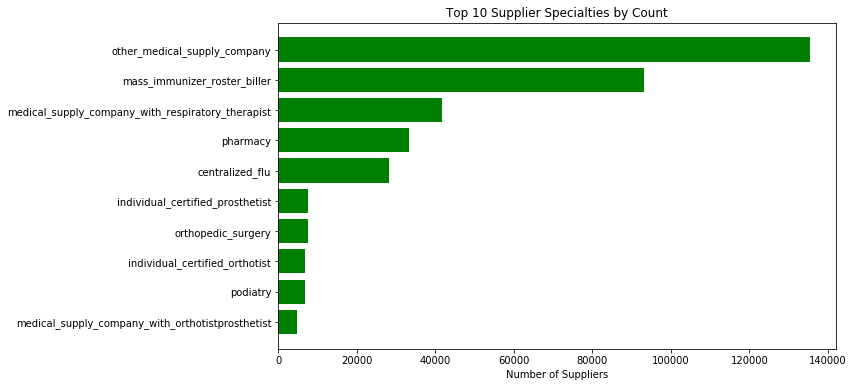

In [18]:
#Simple visuals:

#Top 10 Supplier Specialties by Count
top_specialties = (df_clean.groupby("Suplr_Prvdr_Spclty_Desc").size().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,6))
plt.barh(top_specialties.index.tolist(), top_specialties.values.tolist(), color='green')
plt.title("Top 10 Supplier Specialties by Count")
plt.xlabel("Number of Suppliers")
plt.gca().invert_yaxis()
plt.show()

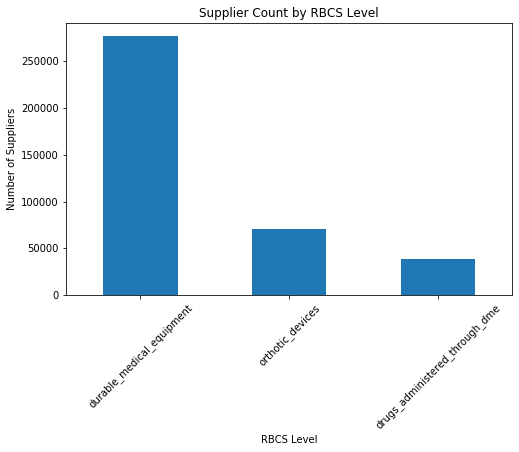

In [19]:
#Supplier Count by RBCS Level
df_clean.groupby("RBCS_Lvl").size().sort_values(ascending=False).plot(kind="bar",legend=False,figsize=(8,5))

plt.title("Supplier Count by RBCS Level")
plt.xlabel("RBCS Level")
plt.ylabel("Number of Suppliers")
plt.xticks(rotation=45)
plt.show()

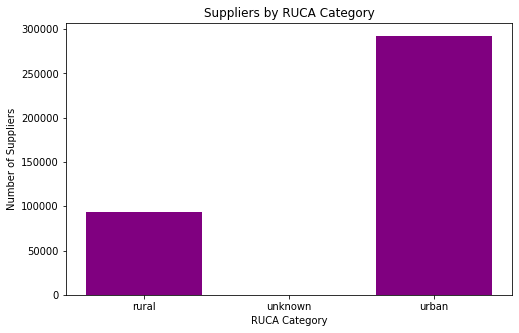

In [20]:
#Suppliers by RUCA Category

ruca_counts = df_clean.groupby("Suplr_Prvdr_RUCA_Cat").size().sort_index()

plt.figure(figsize=(8,5))
plt.bar(ruca_counts.index.tolist(), ruca_counts.values.tolist(), color='purple')
plt.title("Suppliers by RUCA Category")
plt.xlabel("RUCA Category")
plt.ylabel("Number of Suppliers")
plt.show()

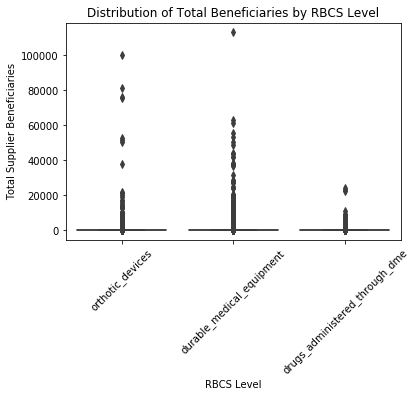

In [21]:
# Distribution of Total Beneficiaries by RBCS Level

sns.boxplot(data=df_clean, x="RBCS_Lvl", y="Tot_Suplr_Benes")
plt.title("Distribution of Total Beneficiaries by RBCS Level")
plt.xlabel("RBCS Level")
plt.ylabel("Total Supplier Beneficiaries")
plt.xticks(rotation=45)
plt.show()

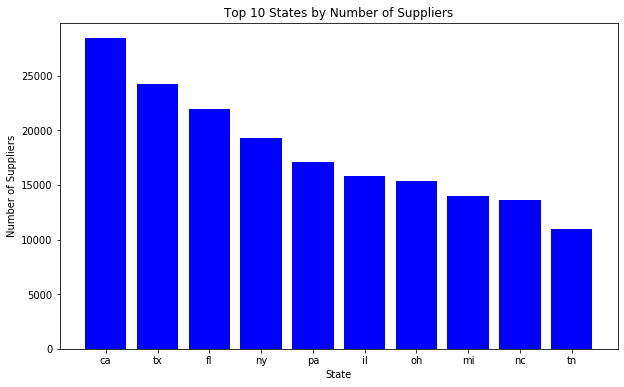

In [22]:
# Top 10 States by Number of Suppliers
state_counts = df_clean.groupby("Suplr_Prvdr_State_Abrvtn").size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(state_counts.index.tolist(), state_counts.values.tolist(), color='blue')
plt.title("Top 10 States by Number of Suppliers")
plt.xlabel("State")
plt.ylabel("Number of Suppliers")
plt.show()